# **Análisis Familiar**

**Responsabilidades:**

*   Explorar variables relacionadas con familia
*   Analizar estado civil, hijos, convivencia
*   Identificar patrones familiares

In [20]:
# analisis_familiar.py
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns

In [2]:
#Conectar a drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Leer los datos
df = pd.read_excel('/content/drive/MyDrive/Python/JEFAB_2024_limpio.xlsx')

In [4]:
# Explorar estructura básica
print("=== INFORMACIÓN GENERAL ===")
print(f"Total de registros: {len(df)}")
print(f"Total de columnas: {len(df.columns)}")

=== INFORMACIÓN GENERAL ===
Total de registros: 6423
Total de columnas: 61


# **Preguntas**
1. ¿Qué porcentaje del personal está casado?
2. ¿Cuántos tienen hijos y cuántos viven con ellos?
3. ¿Hay relación entre edad y estado civil?

# **1. ¿Qué porcentaje del personal está casado?**

In [5]:
# Análisis de estado civil
print("=== ANÁLISIS ESTADO CIVIL ===")
print(df['ESTADO_CIVIL'].value_counts())

=== ANÁLISIS ESTADO CIVIL ===
ESTADO_CIVIL
CASADO        3889
SOLTEROA      2084
DIVORCIADO     250
SEPARADO       161
VIUDOA          39
Name: count, dtype: int64


In [6]:
# Porcentaje de personas segun su estado civil
print("\n=== PROPORCION POR ESTADO CIVIL===")
print(df['ESTADO_CIVIL'].value_counts(normalize=True) * 100)


=== PROPORCION POR ESTADO CIVIL===
ESTADO_CIVIL
CASADO        60.548031
SOLTEROA      32.445898
DIVORCIADO     3.892262
SEPARADO       2.506617
VIUDOA         0.607193
Name: proportion, dtype: float64


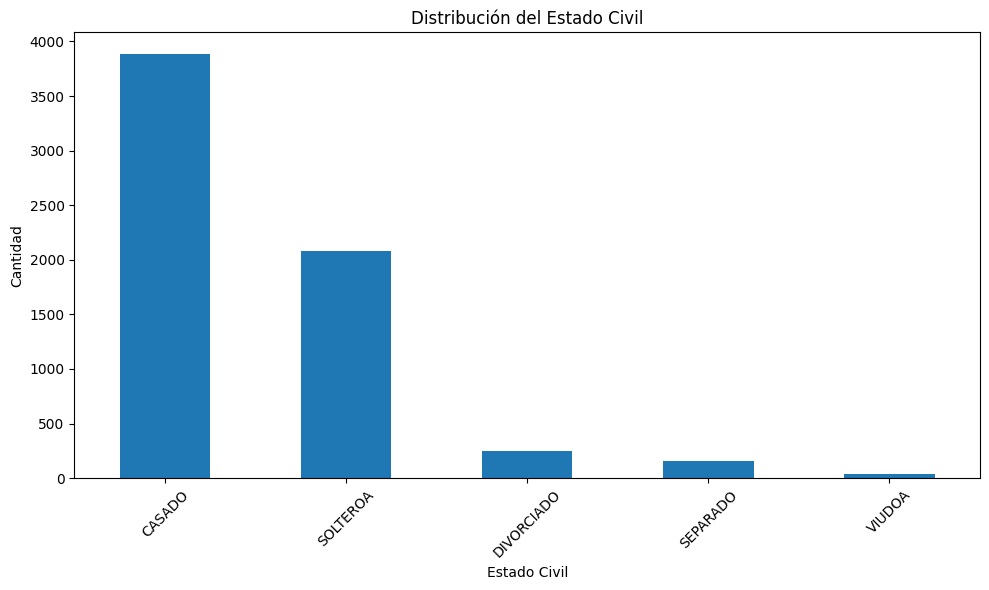

In [7]:
# Gráfico de estado civil
plt.figure(figsize=(10, 6))
df['ESTADO_CIVIL'].value_counts().plot(kind='bar')
plt.title('Distribución del Estado Civil')
plt.xlabel('Estado Civil')
plt.ylabel('Cantidad')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

En este caso el estado civil muestra que la mayor proporción del personal se encuentra casado, con un 60,5% del total. En segundo lugar, se encuentran las personas solteras con un 32,4%. Los demás estados civiles presentan una participación significativamente menor: divorciados (3,9%), separados (2,5%) y viudos/as (0,6%). Estos resultados indican que la mayoría de la población encuestada se compone de individuos casados.

# **2. ¿Cuántos tienen hijos y cuántos viven con ellos?**

In [8]:
# Cantidad de personas con o sin hijos
print("\n=== ANÁLISIS DE HIJOS ===")
print(f"Personal con hijos: {df['HIJOS'].value_counts()}")


=== ANÁLISIS DE HIJOS ===
Personal con hijos: HIJOS
SI    3669
NO    2754
Name: count, dtype: int64


In [9]:
# Porcentaje de personas con o sin hijos
print("\n=== PROPORCION DE PERSONAS CON HIJOS ===")
print(df['HIJOS'].value_counts(normalize=True) * 100)


=== PROPORCION DE PERSONAS CON HIJOS ===
HIJOS
SI    57.12284
NO    42.87716
Name: proportion, dtype: float64


In [14]:
# Cantidad de personas con hijos que viven en el hogar
print("\n=== ANÁLISIS DE HIJOS EN HOGAR ===")
print(f"Personal con hijos en hogar:\n{df['HIJOS_EN_HOGAR'].value_counts(normalize=True)*100}")


=== ANÁLISIS DE HIJOS EN HOGAR ===
Personal con hijos en hogar:
HIJOS_EN_HOGAR
0.00000    50.365873
1.00000    24.163164
2.00000    16.082827
1.27552     6.943796
3.00000     2.148529
4.00000     0.249105
5.00000     0.046707
Name: proportion, dtype: float64


Para la variables hijos y convivencia familiar, observamos que el 57,1% del personal tiene hijos. Sin embargo, vemos que de las personas encuestadas el 50.4% no cuenta con sus hijos en el hogar.
 Estos hallazgos sugieren que, aunque la mayoría de los trabajadores son padres, no todos comparten residencia con sus hijos, lo cual puede estar asociado a factores como la independencia residencial, arreglos de custodia o dinámicas familiares particulares.

# **3. ¿Hay relación entre edad y estado civil?**

In [11]:
# Promedio de edad por estado civil
print("\n=== Edad promedio por Estado Civil ===")
print(df.groupby('ESTADO_CIVIL')['EDAD2'].mean())


=== Edad promedio por Estado Civil ===
ESTADO_CIVIL
CASADO        39.681089
DIVORCIADO    40.352000
SEPARADO      40.875776
SOLTEROA      30.233012
VIUDOA        47.564103
Name: EDAD2, dtype: float64


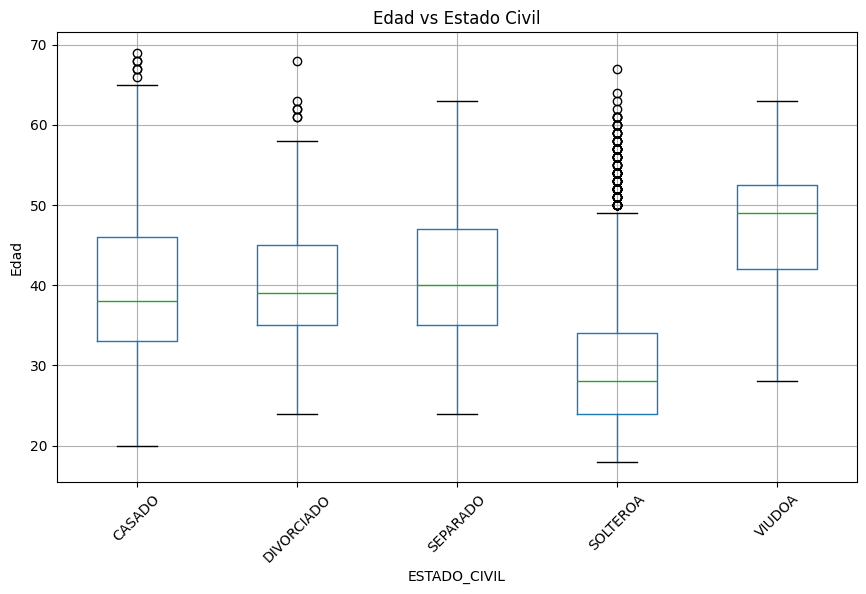

In [12]:
# Distribución por edad y estado civil
df.boxplot(column='EDAD2', by='ESTADO_CIVIL', figsize=(10,6))
plt.title("Edad vs Estado Civil")
plt.suptitle("")
plt.ylabel("Edad")
plt.xticks(rotation=45)
plt.show()

El análisis de la relación entre edad y estado civil evidencia patrones claros. Las personas solteras presentan la edad promedio más baja (30,2 años), mientras que los casados, divorciados y separados registran promedios similares (entre 39 y 41 años). Finalmente, los viudos/as se ubican como el grupo de mayor edad promedio, con 47,5 años.
La visualización mediante el diagrama de caja confirma que los solteros concentran edades jóvenes, mientras que la viudez aparece asociada a edades mayores. Por lo que podriamos indicar que sí existe una relación entre la edad y el estado civil, donde las etapas del ciclo vital influyen en la condición marital predominante

# Hallazgos adicionales

In [18]:
# Crear variable booleana: tiene hijos en hogar o no
df['HIJOS_EN_HOGAR_BIN'] = df['HIJOS_EN_HOGAR'] > 0

# Tabla de contingencia
tabla = pd.crosstab(df['HIJOS_EN_HOGAR_BIN'], df['RELACION_HIJOS'])

# Prueba Chi-cuadrado
chi2, p, dof, ex = stats.chi2_contingency(tabla)

print("Tabla de contingencia:\n", tabla)
print(f"\nChi-cuadrado = {chi2:.3f}, p-valor = {p:.3f}")

if p < 0.05:
    print("Existe asociación significativa entre tener hijos en hogar y la relación con ellos.")
else:
    print("No hay asociación significativa entre tener hijos en hogar y la relación con ellos.")


Tabla de contingencia:
 RELACION_HIJOS      CERCANA  CERCANA CON CONFLICTO  CONFLICTIVA  DISTANTE  \
HIJOS_EN_HOGAR_BIN                                                          
False                   412                     13            0        47   
True                   2681                     52            3        13   

RELACION_HIJOS      NO APLICA  NO RESPONDE  OTRO  
HIJOS_EN_HOGAR_BIN                                
False                       1         2754     8  
True                        0          427    12  

Chi-cuadrado = 3414.098, p-valor = 0.000
Existe asociación significativa entre tener hijos en hogar y la relación con ellos.


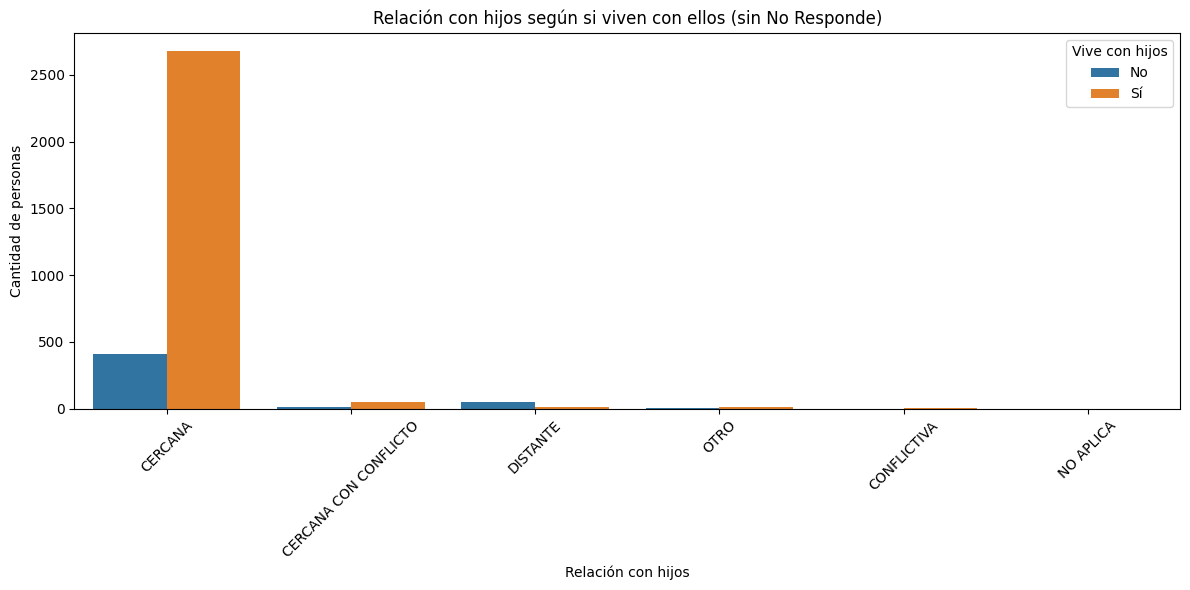

In [22]:
# Filtrar para quitar la categoría "NO RESPONDE" en RELACION_HIJOS
df_filtrado = df[df['RELACION_HIJOS'] != "NO RESPONDE"]

# Gráfico de barras apiladas o countplot sin "NO RESPONDE"
plt.figure(figsize=(12, 6))
sns.countplot(data=df_filtrado, x='RELACION_HIJOS', hue='HIJOS_EN_HOGAR_BIN')
plt.title('Relación con hijos según si viven con ellos (sin No Responde)')
plt.xlabel('Relación con hijos')
plt.ylabel('Cantidad de personas')
plt.xticks(rotation=45)
plt.legend(title='Vive con hijos', labels=['No', 'Sí'])
plt.tight_layout()
plt.show()

El análisis muestra una asociación significativa entre tener hijos en el hogar y el tipo de relación con ellos, según la prueba Chi-cuadrado (chi2 = 3414.098, p < 0.001). Esto indica que la calidad o tipo de relación con los hijos varía dependiendo de si los hijos viven o no en el hogar.

La tabla de contingencia y el gráfico apoyan estos resultados:

Las personas que tienen hijos en el hogar reportan mayoritariamente una relación "CERCANA".

Las personas sin hijos en el hogar tienen un alto porcentaje que "NO RESPONDE" o reportan relaciones "DISTANTES".

Este resultado es relevante para entender la dinámica familiar y cómo la convivencia afecta la relación parental.